In [1]:
from dlfs.modules import SequentialWrapper, VAE
from dlfs.layers import DenseLayer, ConvLayer, ConvTransposeLayer, ReshapeLayer
from dlfs.activation import ReLU, Sigmoid

from dlfs.loss import BCE_Loss, VAE_Loss
from dlfs.optimizers import Optimizer_Adam

from dlfs.helpers import DLFSData

import numpy as np
import matplotlib.pyplot as plt

# Variational Autoencoder Latent Space Visualization

- in this notebook two VAEs are trained with different latent dimensions

- first VAE model's latent space is 2D which is easily visualised

- other VAE model's latent space is 128D and is visualised using dimensionality reduction methods t-SNE and PCA

In [2]:
def build_conv_vae(latent_dim, loss_fn, optimizer):
    
    # Encoder
    enc = SequentialWrapper(
        [ConvLayer(1, 32, 4, stride=2, padding=1),
         ReLU(),
         ConvLayer(32, 64, 4, stride=2, padding=1),
         ReLU(),
         ReshapeLayer(input_shape=(64, 7, 7), output_shape=(64*7*7, ))]
    )

    # Mean feedforward
    mu = SequentialWrapper(
        [DenseLayer(64*7*7, latent_dim)]
    )

    # Log variance feedforward
    logvar = SequentialWrapper(
        [DenseLayer(64*7*7, latent_dim)]
    )

    # Decoder
    dec = SequentialWrapper(
        [DenseLayer(latent_dim, 64*7*7),
         ReshapeLayer(input_shape=(64*7*7, ), output_shape=(64, 7, 7)),
         ConvTransposeLayer(64, 32, 4, stride=2, padding=1),
         ReLU(),
         ConvTransposeLayer(32, 1, 4, stride=2, padding=1),
         Sigmoid()]
    )

    model = VAE(encoder=enc, 
                decoder=dec, 
                mu=mu, 
                logvar=logvar, 
                loss_function = loss_fn,
                optimizer=optimizer)
    
    return model

# Load data

In [3]:
mnist_path = "../data/mnist"

X_train, y_train, X_test, y_test = DLFSData.load_MNIST(mnist_path)

print(f'X_train: {X_train.shape}, y_train: {y_train.shape}')
print(f'X_test: {X_test.shape}, y_test: {y_test.shape}')

X_train: (60000, 28, 28), y_train: (60000,)
X_test: (10000, 28, 28), y_test: (10000,)


In [4]:
samples_per_class = 100

# Selecting images with labels 0, 1, 3 and 7
X_train_2d, y_train_2d = DLFSData.select_MNIST_labels(X_train, 
                                                y_train, 
                                                labels=[0, 1, 3, 7], 
                                                limit=samples_per_class, 
                                                shuffle=False, 
                                                return_dict=False)

classes = np.unique(y_train_2d)

# Normalize train data to (0, 1), reshape to (B, C, H, W)
X_train_2d = DLFSData.normalize_MNIST(X_train_2d, range=(0, 1)).reshape(-1, 1, 28, 28)

print(f'X_train_2d: {X_train_2d.shape}')

X_train_2d: (400, 1, 28, 28)


# VAE with 2D latent space

In [5]:
latent_dim = 2

lr = 1e-3
epochs = 1000
batch_size = None

loss_fn = VAE_Loss(recon_loss=BCE_Loss)
optimizer = Optimizer_Adam(learning_rate=lr)

vae2d = build_conv_vae(latent_dim, loss_fn, optimizer)

vae2d.train(X_train_2d, epochs=epochs, batch_size=batch_size, print_every=100, kl_warmup_steps=150)

===== EPOCH : 0 ===== LOSS : 0.69093 (Recon: 0.69092 | KL: 0.00001)
===== EPOCH : 100 ===== LOSS : 7.24229 (Recon: 0.24500 | KL: 6.99729)
===== EPOCH : 200 ===== LOSS : 6.02351 (Recon: 0.21178 | KL: 5.81173)
===== EPOCH : 300 ===== LOSS : 6.30275 (Recon: 0.19217 | KL: 6.11058)
===== EPOCH : 400 ===== LOSS : 6.58796 (Recon: 0.17308 | KL: 6.41489)
===== EPOCH : 500 ===== LOSS : 6.50802 (Recon: 0.16402 | KL: 6.34400)
===== EPOCH : 600 ===== LOSS : 6.48306 (Recon: 0.15833 | KL: 6.32474)
===== EPOCH : 700 ===== LOSS : 6.64326 (Recon: 0.15417 | KL: 6.48908)
===== EPOCH : 800 ===== LOSS : 6.66713 (Recon: 0.15104 | KL: 6.51609)
===== EPOCH : 900 ===== LOSS : 6.71980 (Recon: 0.14811 | KL: 6.57169)
===== EPOCH : 1000 ===== LOSS : 6.74768 (Recon: 0.14602 | KL: 6.60166)


# Gather $\mu$ and $\sigma$ for each image from encoder

In [6]:
vae2d.encoder.forward(X_train_2d, training=False)
vae2d.mu.forward(vae2d.encoder.output, training=False)
vae2d.logvar.forward(vae2d.encoder.output, training=False)

Z_mu = vae2d.mu.output.copy()
Z_sigma = np.exp(0.5 * vae2d.logvar.output)

# Helper functions for plotting

In [ ]:
from matplotlib.patches import Ellipse

def get_centroid_ellipse(points, color, ellipse_scale=1):
    centroid = points.mean(axis=0)
    cov = np.cov(points.T)
    eigvals, eigvecs = np.linalg.eigh(cov)
    order = eigvals.argsort()[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]

    r1, r2 = np.sqrt(eigvals[0]), np.sqrt(eigvals[1])

    width  = ellipse_scale * 2 * r1
    height = ellipse_scale * 2 * r2
    angle = np.degrees(np.arctan2(eigvecs[1, 0], eigvecs[0, 0]))

    ellipse = Ellipse(
        xy=centroid,
        width=width,
        height=height,
        angle=angle,
        edgecolor=color,
        alpha=0.5,
        fill=False
    )

    return centroid, ellipse

def display_centroid(ax, centroid, class_idx, color):

    ax.plot(centroid[0], centroid[1], linestyle='none',
            marker='*', markersize=12,
            markeredgecolor='black',
            markerfacecolor=color,
            markeredgewidth=1.5, label=f'Class {class_idx} centroid')

def display_point_sigma(ax, mu, sigma, color):
    for m, s in zip(mu, sigma):
        ellipse = Ellipse(
            xy=m,
            width=2*s[0],
            height=2*s[1],
            angle=0,
            facecolor='none',
            edgecolor=color,
            alpha=0.6
        )
        ax.add_patch(ellipse)

def display_standard_sigma(ax):
    for sigma in [1, 2, 3]:
        normal_ellipse = Ellipse(
            xy=(0, 0),
            width=2*sigma,
            height=2*sigma,
            angle=0,
            fill=False,
            edgecolor='gray',
            linewidth=2,
            alpha=1 / sigma
        )
        ax.add_patch(normal_ellipse)

# Plot 2D latent space

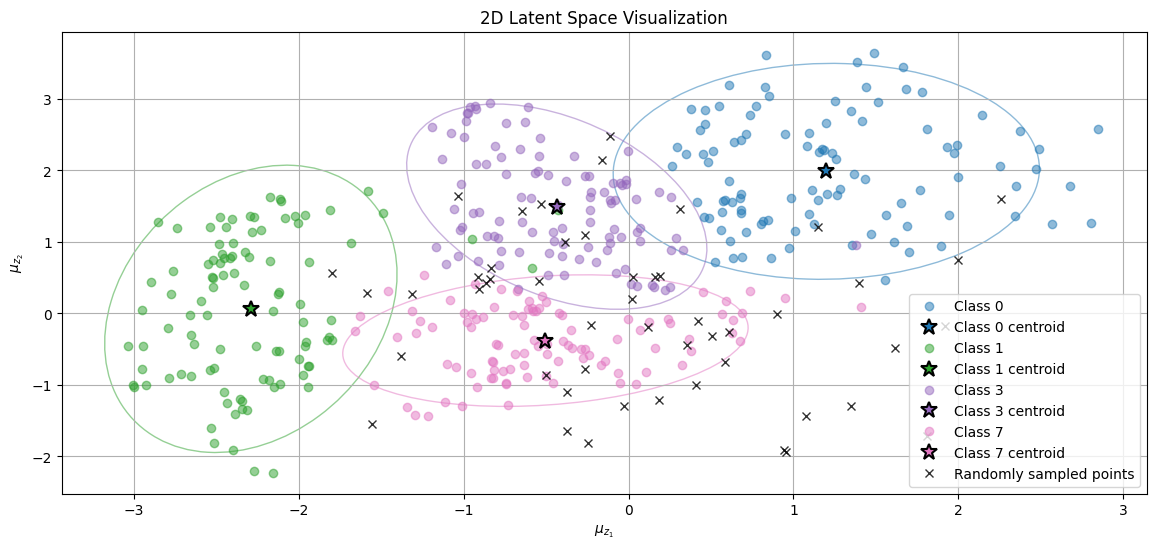

In [9]:
fig, ax = plt.subplots(figsize=(14, 6))

# Whether each data point (mu) will be plotted with its respective sigma ellipse
plot_point_sigma = False

# Whether each class will be plotted with its respective sigma ellipse
plot_class_sigma = True

# Whether standard normal N(0, 1) sigma ellipse will be plotted
plot_standard_sigma = False

n_samples = 100

for c in classes:

    # Filter mu and sigma by class, take n_samples
    class_mu = Z_mu[y_train_2d == c][:n_samples]
    class_sigma = Z_sigma[y_train_2d == c][:n_samples]

    # Plot mu in 2D latent space
    pts = ax.plot(class_mu[:, 0], class_mu[:, 1], 'o', alpha=0.5, label=f"Class {c}")
    color = pts[0].get_color()

    # Optional: plot individual point sigma (logvar from encoder)
    if plot_point_sigma:
        display_point_sigma(ax, class_mu, class_sigma)

    # Calculate class centroid and class standard deviation boundary
    class_centroid, class_ellipse = get_centroid_ellipse(class_mu, color=color, ellipse_scale=2)

    # Plot centroid
    display_centroid(ax, class_centroid, c, color)

    # Optional: plot class sigma ellipse
    if plot_class_sigma:
        ax.add_patch(class_ellipse)

# Plot some random samples from the standard normal N(0, 1)
random_samples = 50
z = np.random.randn(random_samples, latent_dim)
ax.plot(z[:, 0], z[:, 1], 'x', color='black', alpha=0.8, label="Randomly sampled points")

# Optional: plot standard normal sigma ellipse
if plot_standard_sigma:
    # Gray ellipse represents N(0, 1) 1-2-3 sigma
    display_standard_sigma(ax)

ax.set_xlabel(r'$\mu_{z_1}$')
ax.set_ylabel(r'$\mu_{z_2}$')
ax.set_title("2D Latent Space Visualization")
ax.grid(True)
ax.legend()
plt.show()


# Latent space analysis

- all the class points (coloured dots) are plotted in the latent space using their 2D $\mu$ vectors produced by the encoder

- encoder also produces $\log \sigma^2$ for each point but it is not plotted to avoid clutter (optionally it can be plotted)

- class centroids are computed as mean of all class samples to represent class central tendency, for aesthetic purposes

- class coloured ellipses represent class standard deviation (2-3 $\sigma$) and is used to approximately denote the class cluster in latent space

- sampling from standard normal makes random point "land" in one of the class clusters (or not) from which decoder can reconstruct meaningful image

In [10]:
samples_per_class = 100

# Selecting images with labels 0, 1, 3 and 7
X_train_128d, y_train128d = DLFSData.select_MNIST_labels(X_train, 
                                                         y_train, 
                                                         labels=[0, 1, 3, 7], 
                                                         limit=samples_per_class, 
                                                         shuffle=False)

classes = np.unique(y_train128d)

# Normalize train data to (0, 1), reshape to (B, C, H, W)
X_train_128d = DLFSData.normalize_MNIST(X_train_128d, range=(0, 1)).reshape(-1, 1, 28, 28)

print(f'X_train_128d: {X_train_128d.shape}')

X_train_128d: (400, 1, 28, 28)


# VAE with 128D latent space

In [11]:
latent_dim = 128

lr = 1e-3
epochs = 1000
batch_size = None

loss_fn = VAE_Loss(recon_loss=BCE_Loss)
optimizer = Optimizer_Adam(learning_rate=lr)

vae128d = build_conv_vae(latent_dim, loss_fn, optimizer)

vae128d.train(X_train_128d, epochs=epochs, batch_size=batch_size, print_every=100, kl_warmup_steps=200)

===== EPOCH : 0 ===== LOSS : 0.69375 (Recon: 0.69328 | KL: 0.00047)
===== EPOCH : 100 ===== LOSS : 16.19996 (Recon: 0.16556 | KL: 16.03440)
===== EPOCH : 200 ===== LOSS : 25.81453 (Recon: 0.12509 | KL: 25.68945)
===== EPOCH : 300 ===== LOSS : 25.41670 (Recon: 0.10477 | KL: 25.31192)
===== EPOCH : 400 ===== LOSS : 24.66474 (Recon: 0.09587 | KL: 24.56886)
===== EPOCH : 500 ===== LOSS : 24.44641 (Recon: 0.09152 | KL: 24.35489)
===== EPOCH : 600 ===== LOSS : 24.52190 (Recon: 0.08815 | KL: 24.43375)
===== EPOCH : 700 ===== LOSS : 23.77794 (Recon: 0.08794 | KL: 23.69000)
===== EPOCH : 800 ===== LOSS : 23.95803 (Recon: 0.08514 | KL: 23.87290)
===== EPOCH : 900 ===== LOSS : 23.05759 (Recon: 0.08481 | KL: 22.97278)
===== EPOCH : 1000 ===== LOSS : 23.04884 (Recon: 0.08403 | KL: 22.96481)


In [12]:
vae128d.encoder.forward(X_train_128d, training=False)
vae128d.mu.forward(vae128d.encoder.output, training=False)
z_mu = vae128d.mu.output.copy()

# Plot 2D latent space using t-SNE

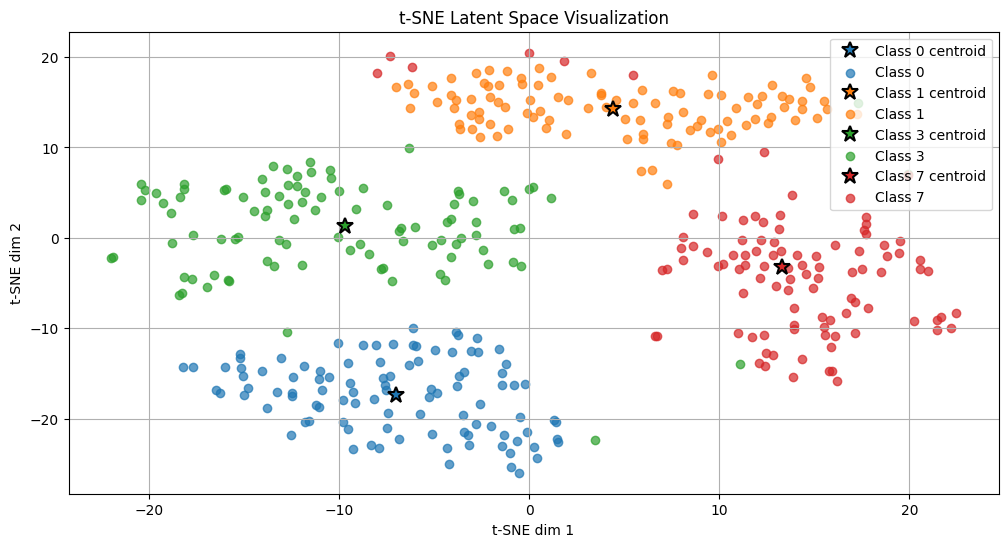

In [18]:
from sklearn.manifold import TSNE

plot_class_sigma = False

tsne = TSNE(n_components=2, random_state=432)
z_tsne = tsne.fit_transform(z_mu)

colors = plt.cm.tab10.colors
fig, ax = plt.subplots(figsize=(12, 6))

for idx, c in enumerate(classes):

    class_color = colors[idx % len(colors)]
    z_class = z_tsne[y_train128d == c]

    # Calculate class centroid and class standard deviation boundary
    class_centroid, class_ellipse = get_centroid_ellipse(z_class, color=class_color, ellipse_scale=2)

    # Plot centroid
    display_centroid(ax, class_centroid, c, color=class_color)

    # Optional: plot class standard deviation ellipse
    if plot_class_sigma:
        ax.add_patch(class_ellipse)

    ax.scatter(z_class[:, 0], z_class[:, 1], color=class_color, label=f'Class {c}',alpha=0.7)

ax.set_xlabel("t-SNE dim 1")
ax.set_ylabel("t-SNE dim 2")
ax.set_title("t-SNE Latent Space Visualization")
ax.grid(True)
ax.legend()
plt.show()

# Plot 2D latent space using PCA

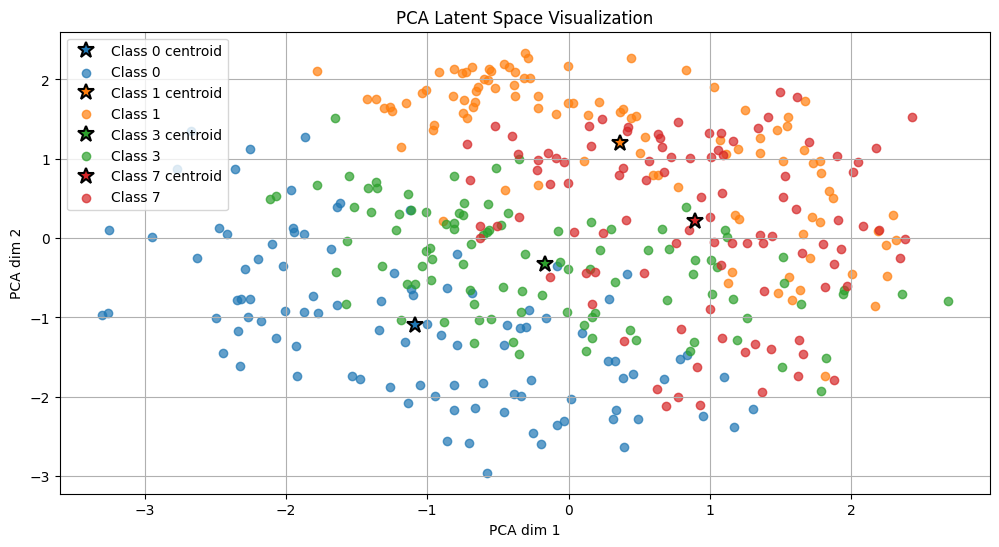

In [20]:
from sklearn.decomposition import PCA

# Whether each class will be plotted with its respective sigma ellipse
plot_class_sigma = False

pca = PCA(n_components=2)
z_pca = pca.fit_transform(z_mu)

colors = plt.cm.tab10.colors
fig, ax = plt.subplots(figsize=(12, 6))

for idx, c in enumerate(classes):

    class_color = colors[idx % len(colors)]
    z_class = z_pca[y_train128d == c]

    # Calculate class centroid and class standard deviation boundary
    class_centroid, class_ellipse = get_centroid_ellipse(z_class, color=class_color, ellipse_scale=2)

    # Plot centroid
    display_centroid(ax, class_centroid, c, color=class_color)

    # Optional: plot class standard deviation ellipse
    if plot_class_sigma:
        ax.add_patch(class_ellipse)

    ax.scatter(z_class[:, 0], z_class[:, 1], color=class_color, label=f'Class {c}',alpha=0.7)

ax.set_xlabel("PCA dim 1")
ax.set_ylabel("PCA dim 2")
ax.set_title("PCA Latent Space Visualization")
ax.grid(True)
ax.legend()
plt.show()